# Unified Geotechnical Data Extraction and Harmonization

This notebook is intentionally limited to data extraction, schema harmonization, quality checking, and export. It reads the raw Excel workbooks, reconciles inconsistent headers and units, removes exact duplicates, and writes dense CSV files for downstream use.

What this notebook does:
1. Inventories the raw workbooks and flags exact duplicate files.
2. Applies consistent naming and unit rules across all sources.
3. Builds a harmonized audit dataframe that still keeps `Source_File` for QA.
4. Creates dense export datasets that remove `Source_File` and unresolved sparsity from the final deliverables.
5. Writes the cleaned CSV files used by the target-specific notebooks.

Files written by this notebook:
- `../outputs/geotechnical_training_ready.csv`
- `../outputs/geotechnical_phi_training_ready.csv`
- `../outputs/geotechnical_cu_training_ready.csv`

In [1]:
from __future__ import annotations

# Standard library imports used for file discovery and duplicate-file hashing.
import hashlib
from pathlib import Path
from typing import Iterable

# Data and plotting libraries used for extraction QA and export review.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Notebook display settings keep the audit tables readable.
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="talk")

# Resolve the project folders once so the rest of the notebook can stay path-safe.
ROOT = Path("..").resolve()
DATA_DIR = ROOT / "datasets"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Collect the raw workbooks that feed the extraction pipeline.
SOURCE_FILES = sorted(DATA_DIR.glob("geotechnical_data_*.xlsx"))
TARGET_COLUMNS = ["Phi_deg", "Cu_kPa"]

print(f"Project root: {ROOT}")
print(f"Workbook count: {len(SOURCE_FILES)}")
pd.DataFrame({"source_file": [path.name for path in SOURCE_FILES]})

Project root: /Users/apple/Downloads/Soil-Properties-Prediction
Workbook count: 10


,source_file
0,geotechnical_data_0.xlsx
1,geotechnical_data_1.xlsx
2,geotechnical_data_2.xlsx
3,geotechnical_data_3.xlsx
4,geotechnical_data_4.xlsx
5,geotechnical_data_5.xlsx
6,geotechnical_data_6.xlsx
7,geotechnical_data_7.xlsx
8,geotechnical_data_8.xlsx
9,geotechnical_data_9.xlsx


In [2]:
def workbook_signature(frame: pd.DataFrame) -> str:
    canonical = frame.copy().sort_index(axis=1)
    canonical = canonical.where(pd.notna(canonical), None)
    payload = canonical.to_json(orient="split", index=False)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

# Inventory each workbook before harmonization so duplicate files are visible up front.
inventory_rows = []
signature_to_files: dict[str, list[str]] = {}

for path in SOURCE_FILES:
    workbook = pd.read_excel(path)
    signature = workbook_signature(workbook)
    inventory_rows.append(
        {
            "source_file": path.name,
            "rows": len(workbook),
            "columns": len(workbook.columns),
            "column_list": list(map(str, workbook.columns)),
        }
    )
    signature_to_files.setdefault(signature, []).append(path.name)

raw_inventory = pd.DataFrame(inventory_rows).sort_values("source_file").reset_index(drop=True)
duplicate_workbook_groups = [files for files in signature_to_files.values() if len(files) > 1]

inventory_summary = pd.Series(
    {
        "workbook_count": len(raw_inventory),
        "total_raw_rows": int(raw_inventory["rows"].sum()),
        "duplicate_workbook_groups": len(duplicate_workbook_groups),
    }
)

display(inventory_summary.to_frame("value"))
display(raw_inventory[["source_file", "rows", "columns"]])

if duplicate_workbook_groups:
    duplicate_group_frame = pd.DataFrame(
        {"duplicate_group": [" | ".join(group) for group in duplicate_workbook_groups]}
    )
    display(duplicate_group_frame)
else:
    print("No duplicate workbook groups were detected.")

,value
workbook_count,10
total_raw_rows,316
duplicate_workbook_groups,1


,source_file,rows,columns
0,geotechnical_data_0.xlsx,20,16
1,geotechnical_data_1.xlsx,16,14
2,geotechnical_data_2.xlsx,27,14
3,geotechnical_data_3.xlsx,18,16
4,geotechnical_data_4.xlsx,43,15
5,geotechnical_data_5.xlsx,43,15
6,geotechnical_data_6.xlsx,34,14
7,geotechnical_data_7.xlsx,48,15
8,geotechnical_data_8.xlsx,42,13
9,geotechnical_data_9.xlsx,25,19


,duplicate_group
0,geotechnical_data_4.xlsx | geotechnical_data_5...


## Harmonization Rules

The raw workbooks are fairly close to one another, but a clean export still needs a few explicit correction rules.

Rules applied in this notebook:
- Normalize header variants such as `LL (%)`, `PL (%)`, and `PI (%)`.
- Convert `Grain_75um` into the canonical `Grain_0.075mm` field.
- Normalize file-8 unit-labelled consolidation headers back to base names.
- Convert density-like values in `Sat_Unit_Wt_kN_m3` into `kN/m³`.
- Split ambiguous SPT storage into blow-count and resistance columns before quality checks.
- Derive consistent coarse, fines, sand, and gravel fractions for the export datasets.

The notebook stops at cleaned dataset creation and export. Modeling is handled separately in the target-specific notebooks.

In [3]:
# Header fixes gathered during workbook profiling.
COLUMN_RENAME_MAP = {
    "LL (%)": "LL",
    "PL (%)": "PL",
    "PI (%)": "PI",
    "Wn_%": "Moisture_Content",
    "SPT_N": "SPT_N_Raw",
    "SPT_kPa": "SPT_Resistance_kPa",
    "Grain_2.00mm (%)": "Grain_2.00mm",
    "Grain_0.425mm (%)": "Grain_0.425mm",
    "Grain_0.075mm (%)": "Grain_0.075mm",
    "Grain_75um": "Grain_0.075mm",
    "Mv_50kPa (m²/MN)x10⁻⁴": "Mv_50kPa",
    "Mv_400kPa (m²/MN)x10⁻⁴": "Mv_400kPa",
    "Cv_50kPa (m²/yr)": "Cv_50kPa",
    "Cv_400kPa (m²/yr)": "Cv_400kPa",
}

# These are the only columns allowed into the dense final exports.
FINAL_EXPORT_COLUMNS = [
    "LL",
    "PL",
    "PI",
    "Sat_Unit_Wt_kN_m3",
    "Mv_50kPa",
    "Cv_50kPa",
    "Grain_CoarsePassing_pct",
    "Fines_Content_pct",
    "Sand_Fraction_pct",
    "Gravel_Fraction_pct",
]

# Broad value limits are used to remove clearly impossible entries without overfitting the cleanup.
VALID_RANGE_COLUMNS = {
    "LL": (0.0, 120.0),
    "PL": (0.0, 80.0),
    "PI": (0.0, 80.0),
    "Moisture_Content": (0.0, 150.0),
    "Sat_Unit_Wt_kN_m3": (10.0, 24.5),
    "Phi_deg": (0.0, 50.0),
    "Cu_kPa": (0.0, 500.0),
    "SPT_BlowCount_N": (0.0, 100.0),
    "SPT_Resistance_kPa": (0.0, 500.0),
    "CPT_MPa": (0.0, 50.0),
    "Grain_4.75mm": (0.0, 100.0),
    "Grain_2.36mm": (0.0, 100.0),
    "Grain_2.00mm": (0.0, 100.0),
    "Grain_0.425mm": (0.0, 100.0),
    "Grain_0.075mm": (0.0, 100.0),
    "Grain_2um": (0.0, 100.0),
}

# Return a numeric series when a column exists, otherwise a same-length NaN series.
def series_or_nan(frame: pd.DataFrame, column: str) -> pd.Series:
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors="coerce")
    return pd.Series(np.nan, index=frame.index, dtype=float)

# Merge duplicate column names that appear after renaming equivalent headers.
def coalesce_duplicate_columns(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()
    duplicate_names = cleaned.columns[cleaned.columns.duplicated()].unique()

    for name in duplicate_names:
        duplicate_block = cleaned.loc[:, cleaned.columns == name]
        cleaned = cleaned.loc[:, cleaned.columns != name]
        cleaned[name] = duplicate_block.bfill(axis=1).iloc[:, 0]

    return cleaned

# Apply the canonical header names discovered during schema review.
def standardize_headers(frame: pd.DataFrame) -> pd.DataFrame:
    standardized = frame.rename(columns=COLUMN_RENAME_MAP)
    return coalesce_duplicate_columns(standardized)

# Convert density-style values such as 1.8 into kN/m3 while leaving true unit weights unchanged.
def convert_unit_weight(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    density_like_mask = numeric.between(0.8, 3.0, inclusive="both")
    numeric.loc[density_like_mask] = numeric.loc[density_like_mask] * 9.81
    return numeric

# Separate the overloaded SPT storage into two clearer fields.
def split_spt_measurements(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()
    raw_n = series_or_nan(cleaned, "SPT_N_Raw")
    raw_resistance = series_or_nan(cleaned, "SPT_Resistance_kPa")

    cleaned["SPT_BlowCount_N"] = raw_n.where(raw_n <= 60)
    cleaned["SPT_Resistance_kPa"] = raw_resistance.combine_first(raw_n.where(raw_n > 60))
    return cleaned.drop(columns=["SPT_N_Raw"], errors="ignore")

# Apply light domain bounds and rebuild PI when LL and PL are available.
def apply_domain_rules(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()

    for column in cleaned.columns:
        if column != "Source_File":
            cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce")

    if "Sat_Unit_Wt_kN_m3" in cleaned.columns:
        cleaned["Sat_Unit_Wt_kN_m3"] = convert_unit_weight(cleaned["Sat_Unit_Wt_kN_m3"])

    if {"LL", "PL"}.issubset(cleaned.columns):
        expected_pi = cleaned["LL"] - cleaned["PL"]
        if "PI" not in cleaned.columns:
            cleaned["PI"] = expected_pi
        else:
            pi_needs_fill = cleaned["PI"].isna() | ((expected_pi - cleaned["PI"]).abs() > 0.5)
            cleaned.loc[pi_needs_fill, "PI"] = expected_pi.loc[pi_needs_fill]

    for column, (low, high) in VALID_RANGE_COLUMNS.items():
        if column in cleaned.columns:
            cleaned[column] = cleaned[column].where(cleaned[column].between(low, high))

    for column in [name for name in cleaned.columns if name.startswith(("Mv_", "Cv_"))]:
        cleaned[column] = cleaned[column].where(cleaned[column] >= 0)

    return cleaned

# Derive the gradation fields used by the dense export datasets.
def add_domain_features(frame: pd.DataFrame) -> pd.DataFrame:
    engineered = frame.copy()
    fines = series_or_nan(engineered, "Grain_0.075mm")
    coarse_passing = series_or_nan(engineered, "Grain_2.00mm").combine_first(
        series_or_nan(engineered, "Grain_2.36mm")
    )

    sand_fraction = coarse_passing - fines
    gravel_fraction = 100.0 - coarse_passing

    engineered["Grain_CoarsePassing_pct"] = coarse_passing.where(coarse_passing.between(0, 100))
    engineered["Fines_Content_pct"] = fines.where(fines.between(0, 100))
    engineered["Sand_Fraction_pct"] = sand_fraction.where(sand_fraction.between(0, 100))
    engineered["Gravel_Fraction_pct"] = gravel_fraction.where(gravel_fraction.between(0, 100))
    return engineered

# Read every workbook, harmonize it in the same way, and then remove exact row duplicates.
def load_and_harmonize(paths: Iterable[Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    merged_frames = []

    for path in paths:
        frame = pd.read_excel(path)
        frame = standardize_headers(frame)
        frame["Source_File"] = path.name
        frame = split_spt_measurements(frame)
        frame = apply_domain_rules(frame)
        frame = add_domain_features(frame)
        merged_frames.append(frame)

    merged = pd.concat(merged_frames, ignore_index=True, sort=False)
    deduped = merged.drop_duplicates(
        subset=[column for column in merged.columns if column != "Source_File"]
    ).reset_index(drop=True)
    return deduped, merged

# Build the dense joint and target-specific export views from the harmonized audit dataframe.
def build_export_views(audit_frame: pd.DataFrame) -> dict[str, pd.DataFrame]:
    joint_export_df = audit_frame[FINAL_EXPORT_COLUMNS + TARGET_COLUMNS].dropna().reset_index(drop=True)
    phi_export_df = audit_frame[FINAL_EXPORT_COLUMNS + ["Phi_deg"]].dropna().reset_index(drop=True)
    cu_export_df = audit_frame[FINAL_EXPORT_COLUMNS + ["Cu_kPa"]].dropna().reset_index(drop=True)

    export_summary = pd.DataFrame(
        [
            {
                "dataset": "harmonized_audit_internal",
                "rows": len(audit_frame),
                "columns": audit_frame.shape[1],
                "contains_source_file": True,
                "contains_missing_values": bool(audit_frame.isna().any().any()),
            },
            {
                "dataset": "training_ready_joint",
                "rows": len(joint_export_df),
                "columns": joint_export_df.shape[1],
                "contains_source_file": False,
                "contains_missing_values": bool(joint_export_df.isna().any().any()),
            },
            {
                "dataset": "training_ready_phi",
                "rows": len(phi_export_df),
                "columns": phi_export_df.shape[1],
                "contains_source_file": False,
                "contains_missing_values": bool(phi_export_df.isna().any().any()),
            },
            {
                "dataset": "training_ready_cu",
                "rows": len(cu_export_df),
                "columns": cu_export_df.shape[1],
                "contains_source_file": False,
                "contains_missing_values": bool(cu_export_df.isna().any().any()),
            },
        ]
    )

    joint_missingness = joint_export_df.isna().sum().to_frame(name="missing_count")
    return {
        "joint_export_df": joint_export_df,
        "phi_export_df": phi_export_df,
        "cu_export_df": cu_export_df,
        "export_summary": export_summary,
        "joint_missingness": joint_missingness,
    }

In [4]:
# Run the extraction pipeline once and keep both the audit copy and the dense export copies.
geotechnical_audit_df, raw_merged_df = load_and_harmonize(SOURCE_FILES)
duplicate_rows_removed = len(raw_merged_df) - len(geotechnical_audit_df)

# Build the dense outputs used by the downstream target-specific notebooks.
export_views = build_export_views(geotechnical_audit_df)
geotechnical_df = export_views["joint_export_df"].copy()
phi_training_df = export_views["phi_export_df"].copy()
cu_training_df = export_views["cu_export_df"].copy()
export_summary = export_views["export_summary"].copy()
joint_missingness = export_views["joint_missingness"].copy()

# Keep a per-workbook coverage table for QA. This stays in the notebook and is not exported.
source_summary = (
    geotechnical_audit_df.groupby("Source_File")
    .agg(
        rows=("Source_File", "size"),
        phi_non_null=("Phi_deg", lambda series: series.notna().sum()),
        cu_non_null=("Cu_kPa", lambda series: series.notna().sum()),
    )
    .sort_index()
)

# Write the clean CSV outputs that downstream notebooks consume.
training_ready_path = OUTPUT_DIR / "geotechnical_training_ready.csv"
phi_training_path = OUTPUT_DIR / "geotechnical_phi_training_ready.csv"
cu_training_path = OUTPUT_DIR / "geotechnical_cu_training_ready.csv"

geotechnical_df.to_csv(training_ready_path, index=False)
phi_training_df.to_csv(phi_training_path, index=False)
cu_training_df.to_csv(cu_training_path, index=False)

pipeline_summary = pd.Series(
    {
        "Rows before deduplication": len(raw_merged_df),
        "Rows after deduplication": len(geotechnical_audit_df),
        "Exact duplicate rows removed": duplicate_rows_removed,
        "Joint export rows": len(geotechnical_df),
        "Phi export rows": len(phi_training_df),
        "Cu export rows": len(cu_training_df),
    }
)

print("`Source_File` remains only in the internal audit dataframe for QA.")
display(pipeline_summary.to_frame("value"))
display(export_summary)
display(joint_missingness)
display(source_summary)

`Source_File` remains only in the internal audit dataframe for QA.


,value
Rows before deduplication,316
Rows after deduplication,258
Exact duplicate rows removed,58
Joint export rows,227
Phi export rows,228
Cu export rows,227


,dataset,rows,columns,contains_source_file,contains_missing_values
0,harmonized_audit_internal,258,30,True,True
1,training_ready_joint,227,12,False,False
2,training_ready_phi,228,11,False,False
3,training_ready_cu,227,11,False,False


,missing_count
LL,0
PL,0
PI,0
Sat_Unit_Wt_kN_m3,0
Mv_50kPa,0
Cv_50kPa,0
Grain_CoarsePassing_pct,0
Fines_Content_pct,0
Sand_Fraction_pct,0
Gravel_Fraction_pct,0


,rows,phi_non_null,cu_non_null
Source_File,,,
geotechnical_data_0.xlsx,17,15,15
geotechnical_data_1.xlsx,16,16,16
geotechnical_data_2.xlsx,27,27,27
geotechnical_data_3.xlsx,18,18,18
geotechnical_data_4.xlsx,43,43,43
geotechnical_data_6.xlsx,34,34,33
geotechnical_data_7.xlsx,45,44,44
geotechnical_data_8.xlsx,42,42,42
geotechnical_data_9.xlsx,16,16,16


In [5]:
# Preview the cleaned datasets so the notebook ends with the actual exported tables, not the sparse audit copy.
preview_summary = pd.DataFrame(
    [
        {
            "dataset": "joint_training_ready",
            "rows": len(geotechnical_df),
            "columns": geotechnical_df.shape[1],
        },
        {
            "dataset": "phi_training_ready",
            "rows": len(phi_training_df),
            "columns": phi_training_df.shape[1],
        },
        {
            "dataset": "cu_training_ready",
            "rows": len(cu_training_df),
            "columns": cu_training_df.shape[1],
        },
    ]
)

display(preview_summary)
display(geotechnical_df.head(10))
display(phi_training_df.head(5))
display(cu_training_df.head(5))

,dataset,rows,columns
0,joint_training_ready,227,12
1,phi_training_ready,228,11
2,cu_training_ready,227,11


,LL,PL,PI,Sat_Unit_Wt_kN_m3,Mv_50kPa,Cv_50kPa,Grain_CoarsePassing_pct,Fines_Content_pct,Sand_Fraction_pct,Gravel_Fraction_pct,Phi_deg,Cu_kPa
0,47.000,35.500,11.500,18.835,0.470,0.850,99.200,36.500,62.700,0.800,10.000,40.800
1,48.500,36.400,12.100,18.933,0.500,0.910,98.500,35.200,63.300,1.500,12.000,48.500
2,44.800,30.800,14.000,18.443,0.390,0.950,98.600,45.300,53.300,1.400,15.000,66.500
3,48.000,37.000,11.000,19.228,0.490,0.850,97.600,38.500,59.100,2.400,16.000,55.400
4,46.500,36.700,9.800,19.326,0.410,0.720,96.800,36.300,60.500,3.200,16.000,42.200
5,47.600,36.400,11.200,18.835,0.470,0.750,99.300,34.500,64.800,0.700,12.000,41.800
6,48.100,36.100,12.000,18.933,0.500,0.800,98.700,32.600,66.100,1.300,12.000,46.500
7,44.600,30.600,14.000,18.443,0.390,0.780,98.400,44.100,54.300,1.600,15.000,66.200
8,46.900,37.100,9.800,19.326,0.410,0.560,97.600,38.500,59.100,2.400,16.000,42.200
9,46.900,37.100,9.800,19.326,0.410,0.560,96.800,36.300,60.500,3.200,16.000,42.200


,LL,PL,PI,Sat_Unit_Wt_kN_m3,Mv_50kPa,Cv_50kPa,Grain_CoarsePassing_pct,Fines_Content_pct,Sand_Fraction_pct,Gravel_Fraction_pct,Phi_deg
0,47.000,35.500,11.500,18.835,0.470,0.850,99.200,36.500,62.700,0.800,10.000
1,48.500,36.400,12.100,18.933,0.500,0.910,98.500,35.200,63.300,1.500,12.000
2,44.800,30.800,14.000,18.443,0.390,0.950,98.600,45.300,53.300,1.400,15.000
3,48.000,37.000,11.000,19.228,0.490,0.850,97.600,38.500,59.100,2.400,16.000
4,46.500,36.700,9.800,19.326,0.410,0.720,96.800,36.300,60.500,3.200,16.000


,LL,PL,PI,Sat_Unit_Wt_kN_m3,Mv_50kPa,Cv_50kPa,Grain_CoarsePassing_pct,Fines_Content_pct,Sand_Fraction_pct,Gravel_Fraction_pct,Cu_kPa
0,47.000,35.500,11.500,18.835,0.470,0.850,99.200,36.500,62.700,0.800,40.800
1,48.500,36.400,12.100,18.933,0.500,0.910,98.500,35.200,63.300,1.500,48.500
2,44.800,30.800,14.000,18.443,0.390,0.950,98.600,45.300,53.300,1.400,66.500
3,48.000,37.000,11.000,19.228,0.490,0.850,97.600,38.500,59.100,2.400,55.400
4,46.500,36.700,9.800,19.326,0.410,0.720,96.800,36.300,60.500,3.200,42.200


,column,dtype
0,LL,float64
1,PL,float64
2,PI,float64
3,Sat_Unit_Wt_kN_m3,float64
4,Mv_50kPa,float64
5,Cv_50kPa,float64
6,Grain_CoarsePassing_pct,float64
7,Fines_Content_pct,float64
8,Sand_Fraction_pct,float64
9,Gravel_Fraction_pct,float64


,count,mean,std,min,25%,50%,75%,max
LL,227.000,37.629,14.471,14.900,28.300,38.100,44.800,95.000
PL,227.000,21.969,8.378,3.700,16.800,21.300,27.000,40.600
PI,227.000,15.660,9.026,4.200,11.200,13.100,18.000,56.800
Sat_Unit_Wt_kN_m3,227.000,18.255,1.384,13.538,17.952,18.345,18.933,20.500
Mv_50kPa,227.000,0.406,0.164,0.130,0.295,0.390,0.490,0.940
Cv_50kPa,227.000,0.939,0.428,0.290,0.650,0.840,1.110,2.410
Grain_CoarsePassing_pct,227.000,98.088,2.548,85.000,97.600,98.600,99.950,100.000
Fines_Content_pct,227.000,38.494,12.618,12.000,31.400,36.200,44.000,87.800
Sand_Fraction_pct,227.000,59.594,12.138,10.600,54.000,62.100,67.050,83.000
Gravel_Fraction_pct,227.000,1.912,2.548,0.000,0.050,1.400,2.400,15.000


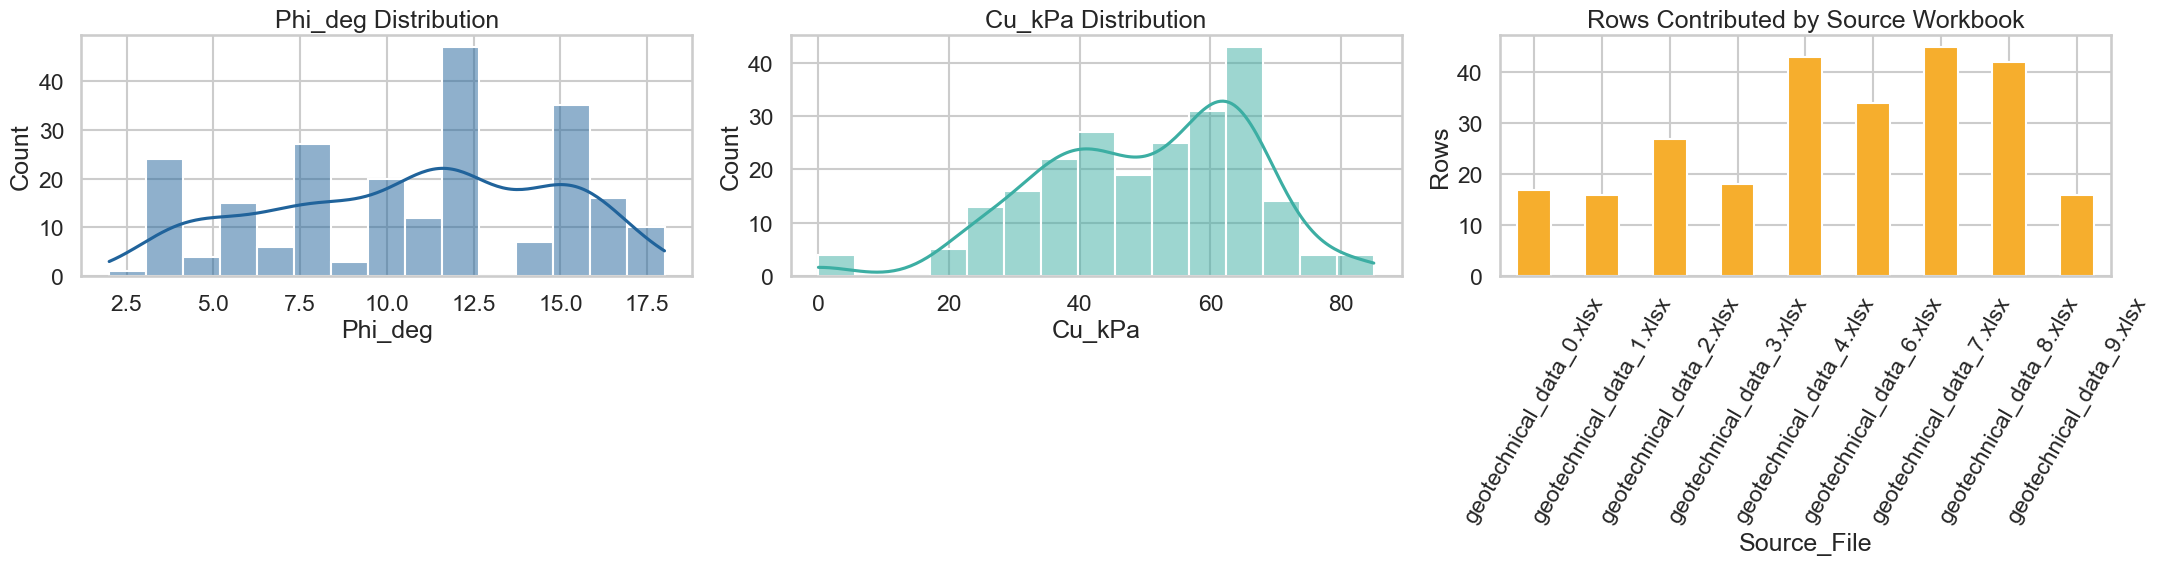

In [6]:
# Summarize the final joint export so the cleaned schema is easy to review.
final_schema = pd.DataFrame(
    {
        "column": geotechnical_df.columns,
        "dtype": geotechnical_df.dtypes.astype(str).values,
    }
)

display(final_schema)
display(geotechnical_df.describe().T)

# Plot the exported target distributions and the per-source row contributions used to build them.
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.histplot(geotechnical_df["Phi_deg"], bins=15, kde=True, ax=axes[0], color="#20639b")
axes[0].set_title("Phi_deg Distribution")
axes[0].set_xlabel("Phi_deg")

sns.histplot(geotechnical_df["Cu_kPa"], bins=15, kde=True, ax=axes[1], color="#3caea3")
axes[1].set_title("Cu_kPa Distribution")
axes[1].set_xlabel("Cu_kPa")

source_summary["rows"].plot(kind="bar", ax=axes[2], color="#f6ae2d")
axes[2].set_title("Rows Contributed by Source Workbook")
axes[2].set_xlabel("Source_File")
axes[2].set_ylabel("Rows")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()